In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

# Create synthetic student data
data = {
    "StudentID": [f"S{i+1}" for i in range(30)],
    "SoftSkills": np.random.randint(1, 11, 30),
    "HardSkills": np.random.randint(1, 11, 30),
    "Creativity": np.random.randint(1, 11, 30),
    "Gender": np.random.choice(["Male", "Female"], 30),
    "Nationality": np.random.choice(["African", "Non-African"], 30, p=[0.3, 0.7])
}

df = pd.DataFrame(data)
df.head()

,StudentID,SoftSkills,HardSkills,Creativity,Gender,Nationality
0,S1,7,9,4,Male,Non-African
1,S2,4,3,6,Male,Non-African
2,S3,8,5,2,Male,Non-African
3,S4,5,3,10,Male,African
4,S5,7,7,2,Female,African


In [2]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Select and scale features
features = df[["SoftSkills", "HardSkills", "Creativity"]]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Apply K-Means
kmeans = KMeans(n_clusters=6, random_state=42)
df["Cluster"] = kmeans.fit_predict(scaled_features)

In [3]:
# Shuffle students within each cluster
clusters = {i: df[df["Cluster"] == i].sample(frac=1, random_state=42).reset_index(drop=True) for i in df["Cluster"].unique()}

# Create empty groups
num_groups = 6
groups = {f"Group {i+1}": [] for i in range(num_groups)}

# Round-robin distribution
group_index = 0
for cluster_df in clusters.values():
    for _, student in cluster_df.iterrows():
        group_name = f"Group {(group_index % num_groups) + 1}"
        groups[group_name].append(student["StudentID"])
        group_index += 1

/tmp/ipython-input-4-493786363.py:19: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


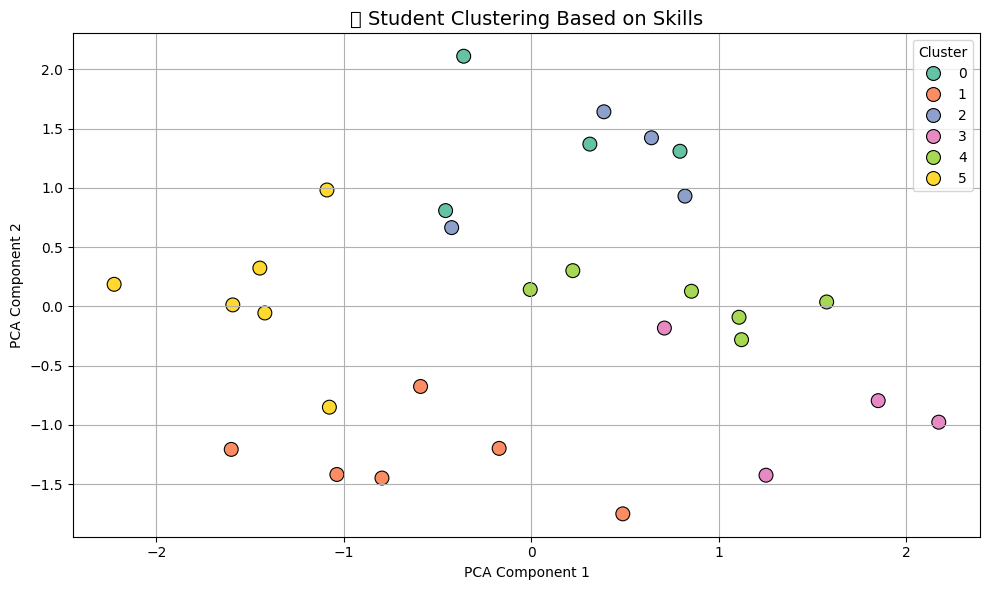

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Reduce to 2D for plotting
pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)
df["PCA1"] = pca_features[:, 0]
df["PCA2"] = pca_features[:, 1]

# Plot clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="PCA1", y="PCA2", hue="Cluster", palette="Set2", s=100, edgecolor="black")
plt.title("📊 Student Clustering Based on Skills", fontsize=14)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()

/tmp/ipython-input-5-858065169.py:16: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


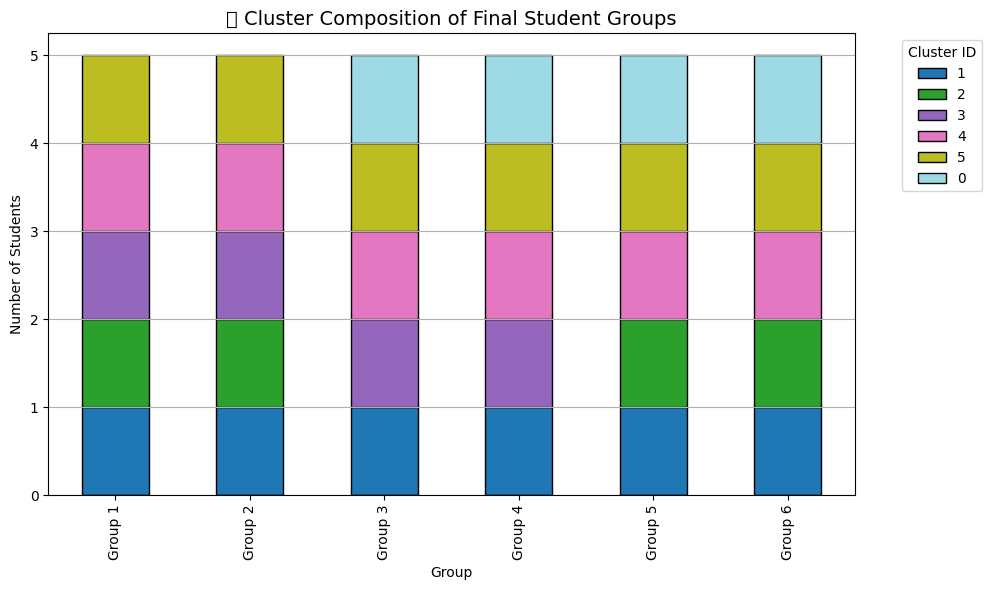

In [5]:
# Build group composition table
group_data = []
for group_name, members in groups.items():
    group_df = df[df["StudentID"].isin(members)]
    cluster_counts = group_df["Cluster"].value_counts().sort_index()
    group_data.append(cluster_counts)

group_df_vis = pd.DataFrame(group_data, index=groups.keys()).fillna(0)

# Plot stacked bar chart
group_df_vis.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="tab20", edgecolor="black")
plt.title("🎯 Cluster Composition of Final Student Groups", fontsize=14)
plt.xlabel("Group")
plt.ylabel("Number of Students")
plt.legend(title="Cluster ID", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(axis="y")
plt.show()

/tmp/ipython-input-6-3679261750.py:20: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


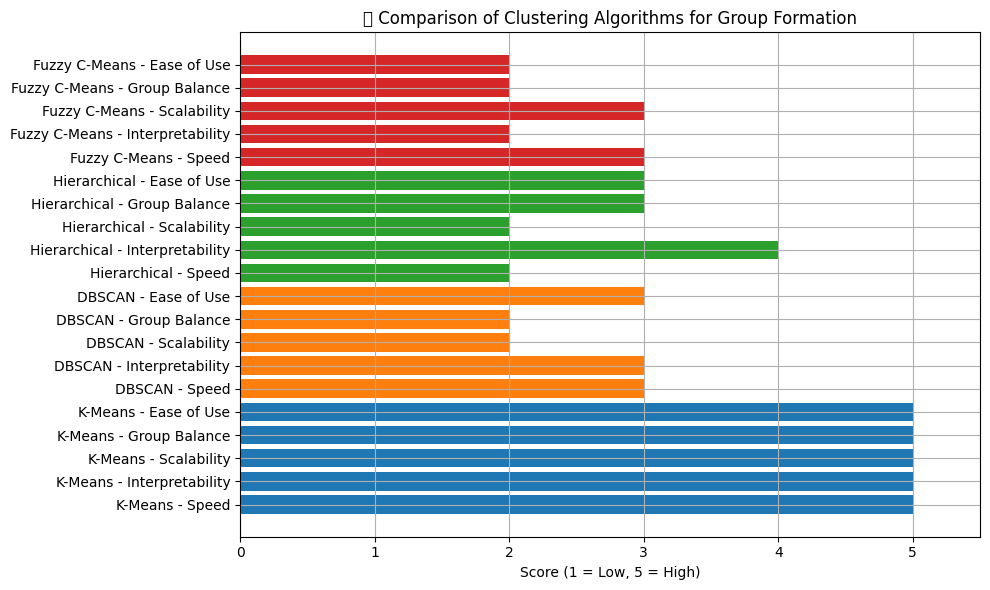

In [6]:
import matplotlib.pyplot as plt

algorithms = ["K-Means", "DBSCAN", "Hierarchical", "Fuzzy C-Means"]
criteria = ["Speed", "Interpretability", "Scalability", "Group Balance", "Ease of Use"]
scores = {
    "K-Means": [5, 5, 5, 5, 5],
    "DBSCAN": [3, 3, 2, 2, 3],
    "Hierarchical": [2, 4, 2, 3, 3],
    "Fuzzy C-Means": [3, 2, 3, 2, 2]
}

fig, ax = plt.subplots(figsize=(10, 6))
for i, algo in enumerate(algorithms):
    ax.barh([f"{algo} - {c}" for c in criteria], scores[algo], label=algo)

plt.title("🔍 Comparison of Clustering Algorithms for Group Formation")
plt.xlabel("Score (1 = Low, 5 = High)")
plt.xlim(0, 5.5)
plt.grid(True)
plt.tight_layout()
plt.show()